# Imports

In [ ]:
! pip install chex

In [ ]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import chex
import typing as t
from functools import partial
import matplotlib.pyplot as plt


# VizUtils

In [ ]:
import os
os.environ['FFMPEG_BINARY'] = 'ffmpeg'
import moviepy.editor as mvp
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from IPython.display import HTML, display, clear_output

class VideoWriter:
  def __init__(self, filename, fps=30.0, **kw):
    self.writer = None
    self.params = dict(filename=filename, fps=fps, **kw)

  def add(self, img):
    img = np.asarray(img)
    if self.writer is None:
      h, w = img.shape[:2]
      self.writer = FFMPEG_VideoWriter(size=(w, h), **self.params)
    if img.dtype in [np.float32, np.float64]:
      img = np.uint8(img.clip(0, 1)*255)
    if len(img.shape) == 2:
      img = np.repeat(img[..., None], 3, -1)
    self.writer.write_frame(img)

  def close(self):
    if self.writer:
      self.writer.close()

  def __enter__(self):
    return self

  def __exit__(self, *kw):
    self.close()

  def show(self, **kw):
      self.close()
      fn = self.params['filename']
      display(mvp.ipython_display(fn, **kw))


# Utils

In [ ]:
def sigmoid(x):
    return 0.5 * (jnp.tanh(x / 2) + 1)

ker_f = lambda x, a, w, b : (b * jnp.exp( - (x[..., None] - a)**2 / w)).sum(-1)

bell = lambda x, m, s: jnp.exp(-((x-m)/s)**2 / 2)

def growth(U, m, s):
    return bell(U, m, s)*2-1

kx = jnp.array([
                [1., 0., -1.],
                [2., 0., -2.],
                [1., 0., -1.]
])
ky = jnp.transpose(kx)
def sobel_x(A):
    """
    A : (x, y, c)
    ret : (x, y, c)
    """
    return jnp.dstack([jsp.signal.convolve2d(A[:, :, c], kx, mode = 'same')
                    for c in range(A.shape[-1])])
def sobel_y(A):
    return jnp.dstack([jsp.signal.convolve2d(A[:, :, c], ky, mode = 'same')
                    for c in range(A.shape[-1])])

@jax.jit
def sobel(A):
    return jnp.concatenate((sobel_y(A)[:, :, None, :], sobel_x(A)[:, :, None, :]),
                            axis = 2)



def get_kernels(SX: int, SY: int, nb_k: int, params):
    mid = SX//2
    Ds = [ np.linalg.norm(np.mgrid[-mid:mid, -mid:mid], axis=0) /
          ((params['R']+15) * params['r'][k]) for k in range(nb_k) ]  # (x,y,k)
    K = jnp.dstack([sigmoid(-(D-1)*10) * ker_f(D, params["a"][k], params["w"][k], params["b"][k])
                    for k, D in zip(range(nb_k), Ds)])
    nK = K / jnp.sum(K, axis=(0,1), keepdims=True)
    return nK


def conn_from_matrix(mat):
    C = mat.shape[0]
    c0 = []
    c1 = [[] for _ in range(C)]
    i = 0
    for s in range(C):
        for t in range(C):
            n = mat[s, t]
            if n:
                c0 = c0 + [s]*n
                c1[t] = c1[t] + list(range(i, i+n))
            i+=n
    return c0, c1


def conn_from_lists(c0, c1, C):
    return c0, [[i == c1[i] for i in range(len(c0))] for c in range(C)]


# Reintegration Tracking

In [ ]:

class ReintegrationTracking:

    def __init__(self, SX=256, SY=256, dt=.2, dd=5, sigma=.65, border="wall", has_hidden=False,
                 hidden_dims=None, mix="softmax"):
        self.SX = SX
        self.SY = SY
        self.dt = dt
        self.dd = dd
        self.sigma = sigma
        self.has_hidden = has_hidden
        self.hidden_dims = hidden_dims
        self.border = border if border in ['wall', 'torus'] else 'wall'
        self.mix = mix

        self.apply = self._build_apply()

    def __call__(self, *args):
        return self.apply(*args)

    def _build_apply(self):

        x, y = jnp.arange(self.SX), jnp.arange(self.SY)
        X, Y = jnp.meshgrid(x, y)
        pos = jnp.dstack((Y, X)) + .5 #(SX, SY, 2)
        dxs = []
        dys = []
        dd = self.dd
        for dx in range(-dd, dd+1):
            for dy in range(-dd, dd+1):
                dxs.append(dx)
                dys.append(dy)
        dxs = jnp.array(dxs)
        dys = jnp.array(dys)
        #-----------------------------------------------------------------------------------------------
        if not self.has_hidden:

            @partial(jax.vmap, in_axes=(None, None, 0, 0))
            def step(X, mu, dx, dy):
                Xr = jnp.roll(X, (dx, dy), axis = (0, 1))
                mur = jnp.roll(mu, (dx, dy), axis = (0, 1))
                if self.border == 'torus':
                    dpmu = jnp.min(jnp.stack(
                        [jnp.absolute(pos[..., None] - (mur + jnp.array([di, dj])[None, None, :, None]))
                        for di in (-self.SX, 0, self.SX) for dj in (-self.SY, 0, self.SY)]
                    ), axis = 0)
                else :
                    dpmu = jnp.absolute(pos[..., None] - mur)
                sz = .5 - dpmu + self.sigma
                area = jnp.prod(jnp.clip(sz, 0, min(1, 2*self.sigma)) , axis = 2) / (4 * self.sigma**2)
                nX = Xr * area
                return nX

            def apply(X, F):

                ma = self.dd - self.sigma  # upper bound of the flow magnitude
                mu = pos[..., None] + jnp.clip(self.dt * F, -ma, ma) #(x, y, 2, c) : target positions (distribution centers)
                if self.border == "wall":
                    mu = jnp.clip(mu, self.sigma, self.SX-self.sigma)
                nX = step(X, mu, dxs, dys).sum(axis = 0)

                return nX
        #-----------------------------------------------------------------------------------------------
        else :



            @partial(jax.vmap, in_axes = (None, None, None, 0, 0))
            def step_flow(X, H, mu, dx, dy):
                """Summary
                """
                Xr = jnp.roll(X, (dx, dy), axis = (0, 1))
                Hr = jnp.roll(H, (dx, dy), axis = (0, 1)) #(x, y, k)
                mur = jnp.roll(mu, (dx, dy), axis = (0, 1))

                if self.border == 'torus':
                    dpmu = jnp.min(jnp.stack(
                        [jnp.absolute(pos[..., None] - (mur + jnp.array([di, dj])[None, None, :, None]))
                        for di in (-self.SX, 0, self.SX) for dj in (-self.SY, 0, self.SY)]
                    ), axis = 0)
                else :
                    dpmu = jnp.absolute(pos[..., None] - mur)

                sz = .5 - dpmu + self.sigma
                area = jnp.prod(jnp.clip(sz, 0, min(1, 2*self.sigma)) , axis = 2) / (4 * self.sigma**2)
                nX = Xr * area
                return nX, Hr

            def apply(X, H, F):

                ma = self.dd - self.sigma  # upper bound of the flow magnitude
                mu = pos[..., None] + jnp.clip(self.dt * F, -ma, ma) #(x, y, 2, c) : target positions (distribution centers)
                if self.border == "wall":
                    mu = jnp.clip(mu, self.sigma, self.SX-self.sigma)
                nX, nH = step_flow(X, H, mu, dxs, dys)

                if self.mix == 'avg':
                    nH = jnp.sum(nH * nX.sum(axis = -1, keepdims = True), axis = 0)
                    nX = jnp.sum(nH, axis = 0)
                    nH = nH / (nX.sum(axis = -1, keepdims = True)+1e-10)

                elif self.mix == "softmax":
                    expnX = jnp.exp(nX.sum(axis = -1, keepdims = True)) - 1
                    nX = jnp.sum(nX, axis = 0)
                    nH = jnp.sum(nH * expnX, axis = 0) / (expnX.sum(axis = 0)+1e-10) #avg rule

                elif self.mix == "stoch":
                    categorical=jax.random.categorical(
                      jax.random.PRNGKey(42),
                      jnp.log(nX.sum(axis = -1, keepdims = True)),
                      axis=0)
                    mask=jax.nn.one_hot(categorical,num_classes=(2*self.dd+1)**2,axis=-1)
                    mask=jnp.transpose(mask,(3,0,1,2))
                    nH = jnp.sum(nH * mask, axis = 0)
                    nX = jnp.sum(nX, axis = 0)

                elif self.mix == "stoch_gene_wise":
                    mask = jnp.concatenate(
                      [jax.nn.one_hot(jax.random.categorical(
                                                            jax.random.PRNGKey(42),
                                                            jnp.log(nX.sum(axis = -1, keepdims = True)),
                                                            axis=0),
                                      num_classes=(2*dd+1)**2,axis=-1)
                      for _ in range(self.hidden_dims)],
                      axis = 2)
                    mask=jnp.transpose(mask,(3,0,1,2)) # (2dd+1**2, x, y, nb_k)
                    nH = jnp.sum(nH * mask, axis = 0)
                    nX = jnp.sum(nX, axis = 0)

                return nX, nH

        return apply



# Flow Lenia

In [ ]:
@chex.dataclass
class Params:
    """Flow Lenia update rule parameters
    """
    r: jnp.ndarray
    b: jnp.ndarray
    w: jnp.ndarray
    a: jnp.ndarray
    m: jnp.ndarray
    s: jnp.ndarray
    h: jnp.ndarray
    R: float


@chex.dataclass
class CompiledParams:
    """Flow Lenia compiled parameters
    """
    fK: jnp.ndarray
    m: jnp.ndarray
    s: jnp.ndarray
    h: jnp.ndarray



class RuleSpace :

    """Rule space for Flow Lenia system

    Attributes:
        kernel_keys (TYPE): Description
        nb_k (int): number of kernels of the system
        spaces (TYPE): Description
    """

    #-----------------------------------------------------------------------------
    def __init__(self, nb_k: int):
        """
        Args:
            nb_k (int): number of kernels in the update rule
        """
        self.nb_k = nb_k
        self.kernel_keys = 'r b w a m s h'.split()
        self.spaces = {
            "r" : {'low' : .2, 'high' : 1., 'mut_std' : .2, 'shape' : None},
            "b" : {'low' : .001, 'high' : 1., 'mut_std' : .2, 'shape' : (3,)},
            "w" : {'low' : .01, 'high' : .5, 'mut_std' : .2, 'shape' : (3,)},
            "a" : {'low' : .0, 'high' : 1., 'mut_std' : .2, 'shape' : (3,)},
            "m" : {'low' : .05, 'high' : .5, 'mut_std' : .2, 'shape' : None},
            "s" : {'low' : .001, 'high' : .18, 'mut_std' : .01, 'shape' : None},
            "h" : {'low' : .01, 'high' : 1., 'mut_std' : .2, 'shape' : None},
            'R' : {'low' : 2., 'high' : 25., 'mut_std' : .2, 'shape' : None},
        }
    #-----------------------------------------------------------------------------
    def sample(self, key: jnp.ndarray)->Params:
        """sample a random set of parameters

        Returns:
            Params: sampled parameters

        Args:
            key (jnp.ndarray): random generation key
        """
        kernels = {}
        for k in 'rmsh':
            key, subkey = jax.random.split(key)
            kernels[k] = jax.random.uniform(
              key=subkey, minval=self.spaces[k]['low'], maxval=self.spaces[k]['high'],
              shape=(self.nb_k,)
            )
        for k in "awb":
            key, subkey = jax.random.split(key)
            kernels[k] = jax.random.uniform(
              key=subkey, minval=self.spaces[k]['low'], maxval=self.spaces[k]['high'],
              shape=(self.nb_k, 3)
            )
        R = jax.random.uniform(key=key, minval=self.spaces['R']['low'], maxval=self.spaces['R']['high'])
        return Params(R=R, **kernels)

class KernelComputer:

    """Summary

    Attributes:
        apply (Callable): main function transforming raw params (Params) in compiled ones (CompiledParams)
        SX (int): X size
        SY (int): Y size
    """

    def __init__(self, SX: int, SY: int, nb_k: int):
        """Summary

        Args:
            SX (int): Description
            SY (int): Description
            nb_k (int): Description
        """
        self.SX = SX
        self.SY = SY

        mid = SX // 2
        def compute_kernels(params: Params)->CompiledParams:
            """Compute kernels and return a dic containing kernels fft

            Args:
                params (Params): raw params of the system

            Returns:
                CompiledParams: compiled params which can be used as update rule
            """

            Ds = [ np.linalg.norm(np.mgrid[-mid:mid, -mid:mid], axis=0) /
                  ((params.R+15) * params.r[k]) for k in range(nb_k) ]  # (x,y,k)
            K = jnp.dstack([sigmoid(-(D-1)*10) * ker_f(D, params.a[k], params.w[k], params.b[k])
                            for k, D in zip(range(nb_k), Ds)])
            nK = K / jnp.sum(K, axis=(0,1), keepdims=True)  # Normalize kernels
            fK = jnp.fft.fft2(jnp.fft.fftshift(nK, axes=(0,1)), axes=(0,1))  # Get kernels fft

            return CompiledParams(fK=fK, m=params.m, s=params.s, h=params.h)

        self.apply = jax.jit(compute_kernels)

    def __call__(self, params: Params):
        """callback to apply
        """
        return self.apply(params)


#==================================================================================================================
#==================================================FLOW LENIA======================================================
#==================================================================================================================

@chex.dataclass
class Config :

    """Configuration of Flow Lenia system
    """
    SX: int
    SY: int
    nb_k: int
    C: int
    c0: t.Iterable
    c1: t.Iterable
    dt: float
    dd: int = 5
    sigma: float = .65
    n: int = 2
    theta_A : float = 1.
    border: str = 'wall'

@chex.dataclass
class State :

    """State of the system
    """
    A: jnp.ndarray

class FlowLenia :

    """class building the main functions of Flow Lenia

    Attributes:
        config (FL_Config): config of the system
        kernel_computer (KernelComputer): kernel computer
        rollout_fn (Callable): rollout function
        RT (ReintegrationTracking): Description
        rule_space (RuleSpace): Rule space of the system
        step_fn (Callable): system step function
    """

    #------------------------------------------------------------------------------

    def __init__(self, config: Config):
        """
        Args:
            config (Config): config of the system
        """
        self.config = config

        self.rule_space = RuleSpace(config.nb_k)

        self.kernel_computer = KernelComputer(self.config.SX, self.config.SY, self.config.nb_k)

        self.RT = ReintegrationTracking(self.config.SX, self.config.SY, self.config.dt,
            self.config.dd, self.config.sigma, self.config.border)

        self.step_fn = self._build_step_fn()

        self.rollout_fn = self._build_rollout()

    #------------------------------------------------------------------------------

    def __call__(self, state: State, params: CompiledParams)->State:
        """callback to step function

        Args:
            state (State): Description
            params (CompiledParams): Description

        Returns:
            State: Description
        """
        return self.step_fn(state, params)

    #------------------------------------------------------------------------------

    def _build_step_fn(self)->t.Callable[[State, CompiledParams], State]:
        """Build step function of the system according to config

        Returns:
            t.Callable[[State, CompiledParams], State]: step function which outputs next state
            given a state and params
        """

        def step(state: State, params: CompiledParams)->State:
            """
            Main step

            Args:
                state (State): state of the system
                params (CompiledParams): params

            Returns:
                State: new state of the system

            """
            #---------------------------Original Lenia------------------------------------
            A = state.A

            fA = jnp.fft.fft2(A, axes=(0,1))  # (x,y,c)

            fAk = fA[:, :, self.config.c0]  # (x,y,k)

            U = jnp.real(jnp.fft.ifft2(params.fK * fAk, axes=(0,1)))  # (x,y,k)

            U = growth(U, params.m, params.s) * params.h  # (x,y,k)

            U = jnp.dstack([ U[:, :, self.config.c1[c]].sum(axis=-1) for c in range(self.config.C) ])  # (x,y,c)

            #-------------------------------FLOW------------------------------------------

            nabla_U = sobel(U) #(x, y, 2, c)

            nabla_A = sobel(A.sum(axis = -1, keepdims = True)) #(x, y, 2, 1)

            alpha = jnp.clip((A[:, :, None, :]/self.config.theta_A)**self.config.n, .0, 1.)

            F = nabla_U * (1 - alpha) - nabla_A * alpha

            nA = self.RT.apply(A, F)

            return State(A=nA)

        return step

    #------------------------------------------------------------------------------

    def _build_rollout(self)->t.Callable[[CompiledParams, State, int], t.Tuple[State, State]]:
        """build rollout function

        Returns:
            t.Callable[[CompiledParams, State, int], t.Tuple[State, State]]: Description
        """
        def scan_step(carry: t.Tuple[State, CompiledParams], x)->t.Tuple[t.Tuple[State, CompiledParams], State]:
            """Summary

            Args:
                carry (t.Tuple[State, CompiledParams]): Description
                x (TYPE): Description

            Returns:
                t.Tuple[t.Tuple[State, CompiledParams], State]: Description
            """
            state, params = carry
            nstate = jax.jit(self.step_fn)(state, params)
            return (nstate, params), nstate

        def rollout(params: CompiledParams, init_state: State, steps: int) -> t.Tuple[State, State]:
            """Summary

            Args:
                params (CompiledParams): Description
                init_state (State): Description
                steps (int): Description

            Returns:
                t.Tuple[State, State]: Description
            """
            return jax.lax.scan(scan_step, (init_state, params), None, length = steps)

        return rollout


# Flow Lenia + Parameter Embedding

In [ ]:
@chex.dataclass
class Config_P(Config):

    """Summary
    """
    mix: str = 'stoch'

@chex.dataclass
class State_P(State):

    """state of system
    """
    P: jnp.ndarray

class FlowLeniaParams:

    """Flow Lenia system with parameters embedding

    Attributes:
        config (TYPE): config of the system
        kernel_computer (TYPE): -
        rollout_fn (TYPE): -
        rule_space (TYPE): -
        step_fn (TYPE): -
    """

    #------------------------------------------------------------------------------

    def __init__(self, config: Config):
        """_

        Args:
            config (Config): config of the system
        """

        self.config = config

        self.rule_space = RuleSpace(config.nb_k)

        self.kernel_computer = KernelComputer(config.SX, config.SY, config.nb_k)

        self.RT = ReintegrationTracking(self.config.SX, self.config.SY, self.config.dt,
            self.config.dd, self.config.sigma, self.config.border, has_hidden=True,
            hidden_dims=self.config.nb_k, mix=self.config.mix)

        self.step_fn = self._build_step_fn()

        self.rollout_fn = self._build_rollout()

    #------------------------------------------------------------------------------

    def _build_step_fn(self)->t.Callable[[State, CompiledParams], State]:
        """build step function

        Returns:
            t.Callable[[State, CompiledParams], State]: step function
        """


        SX, SY, dd, sigma, dt = (self.config.SX, self.config.SY, self.config.dd,
                             self.config.sigma, self.config.dt)


        def step(state: State, params: CompiledParams)->State:
            """
            Main step


            Args:
                state (State): state of the system where A are activations and P is the parameter map
                params (CompiledParams): compiled params of update rule

            Returns:
                State: new state of the systems
            """
            A, P = state.A, state.P
            #---------------------------Original Lenia------------------------------------
            fA = jnp.fft.fft2(A, axes=(0,1))  # (x,y,c)

            fAk = fA[:, :, self.config.c0]  # (x,y,k)

            U = jnp.real(jnp.fft.ifft2(params.fK * fAk, axes=(0,1)))  # (x,y,k)

            U = growth(U, params.m, params.s) * P # (x,y,k)

            U = jnp.dstack([ U[:, :, self.config.c1[c]].sum(axis=-1) for c in range(self.config.C) ])  # (x,y,c)

            #-------------------------------FLOW------------------------------------------

            F = sobel(U) #(x, y, 2, c) : Flow

            C_grad = sobel(A.sum(axis = -1, keepdims = True)) #(x, y, 2, 1) : concentration gradient

            alpha = jnp.clip((A[:, :, None, :]/2)**2, .0, 1.)

            F = jnp.clip(F * (1 - alpha) - C_grad * alpha, - (dd-sigma), dd - sigma)

            nA, nP = self.RT.apply(A, P, F)

            return State_P(A=nA, P=nP)

        return step

    #------------------------------------------------------------------------------

    def _build_rollout(self):
        """build a rollout function taking as input params, an initial state and a number of steps
        and returning the final state of the system and the stacked states

        Returns:
            Callable
        """
        def scan_step(carry: t.Tuple[State, CompiledParams], x)->t.Tuple[t.Tuple[State, CompiledParams], State]:
            """Summary

            Args:
                carry (t.Tuple[State, CompiledParams]): state of the system [state x params]
                x: None

            Returns:
                t.Tuple[t.Tuple[State, CompiledParams], State]: rollout function
            """
            state, params = carry
            nstate = jax.jit(self.step_fn)(state, params)
            return (nstate, params), nstate

        def rollout(params: CompiledParams, init_state: State, steps: int) -> t.Tuple[State, State]:
            """Summary

            Args:
                params (CompiledParams): compiled params of the systems
                init_state (State): initial state of the system
                steps (int): number of steps to simulate

            Returns:
                t.Tuple[State, State]: returns the final state and the stacked states of the rollout
            """
            return jax.lax.scan(scan_step, (init_state, params), None, length = steps)

        return rollout


# Lenia

In [ ]:
class Lenia :

    """class building the main functions of Flow Lenia

    Attributes:
        config (FL_Config): config of the system
        kernel_computer (KernelComputer): kernel computer
        rollout_fn (Callable): rollout function
        RT (ReintegrationTracking): Description
        rule_space (RuleSpace): Rule space of the system
        step_fn (Callable): system step function
    """

    #------------------------------------------------------------------------------

    def __init__(self, config: Config):
        """
        Args:
            config (Config): config of the system
        """
        self.config = config

        self.rule_space = RuleSpace(config.nb_k)

        self.kernel_computer = KernelComputer(self.config.SX, self.config.SY, self.config.nb_k)

        self.RT = ReintegrationTracking(self.config.SX, self.config.SY, self.config.dt,
            self.config.dd, self.config.sigma, self.config.border)

        self.step_fn = self._build_step_fn()

        self.rollout_fn = self._build_rollout()

    #------------------------------------------------------------------------------

    def __call__(self, state: State, params: CompiledParams)->State:
        """callback to step function

        Args:
            state (State): Description
            params (CompiledParams): Description

        Returns:
            State: Description
        """
        return self.step_fn(state, params)

    #------------------------------------------------------------------------------

    def _build_step_fn(self)->t.Callable[[State, CompiledParams], State]:
        """Build step function of the system according to config

        Returns:
            t.Callable[[State, CompiledParams], State]: step function which outputs next state
            given a state and params
        """

        def step(state: State, params: CompiledParams)->State:
            """
            Main step

            Args:
                state (State): state of the system
                params (CompiledParams): params

            Returns:
                State: new state of the system

            """
            #---------------------------Original Lenia------------------------------------
            A = state.A

            fA = jnp.fft.fft2(A, axes=(0,1))  # (x,y,c)

            fAk = fA[:, :, self.config.c0]  # (x,y,k)

            U = jnp.real(jnp.fft.ifft2(params.fK * fAk, axes=(0,1)))  # (x,y,k)

            U = growth(U, params.m, params.s) * params.h  # (x,y,k)

            U = jnp.dstack([ U[:, :, self.config.c1[c]].sum(axis=-1) for c in range(self.config.C) ])  # (x,y,c)

            #-------------------------------FLOW------------------------------------------

            nA = jnp.clip(A + self.config.dt * U, 0., 1.)

            return State(A=nA)

        return step

    #------------------------------------------------------------------------------

    def _build_rollout(self)->t.Callable[[CompiledParams, State, int], t.Tuple[State, State]]:
        """build rollout function

        Returns:
            t.Callable[[CompiledParams, State, int], t.Tuple[State, State]]: Description
        """
        def scan_step(carry: t.Tuple[State, CompiledParams], x)->t.Tuple[t.Tuple[State, CompiledParams], State]:
            """Summary

            Args:
                carry (t.Tuple[State, CompiledParams]): Description
                x (TYPE): Description

            Returns:
                t.Tuple[t.Tuple[State, CompiledParams], State]: Description
            """
            state, params = carry
            nstate = jax.jit(self.step_fn)(state, params)
            return (nstate, params), nstate

        def rollout(params: CompiledParams, init_state: State, steps: int) -> t.Tuple[State, State]:
            """Summary

            Args:
                params (CompiledParams): Description
                init_state (State): Description
                steps (int): Description

            Returns:
                t.Tuple[State, State]: Description
            """
            return jax.lax.scan(scan_step, (init_state, params), None, length = steps)

        return rollout


# Demo

## Lenia

> **Memory optimisation applied here:** Instead of accumulating all `T` frames in GPU memory via `jax.lax.scan`
> (which allocates a stacked array of shape `[T, SX, SY, C]`), we use a **streaming rollout** that runs
> the simulation in fixed-size *chunks* and writes each chunk directly to the video encoder.  
> Only one chunk (of `chunk_size` frames) lives in memory at a time — memory cost is **O(chunk_size)**
> instead of **O(T)**.  The `jax.block_until_ready` call forces the GPU computation to complete before
> we copy data to the CPU, which avoids hidden memory build-up from unevaluated futures.


In [ ]:
#@title Utils
def state2img(A):
    C = A.shape[-1]
    if C == 1:
        return A[..., 0]
    if C == 2:
        return np.dstack([A[..., 0], A[..., 0], A[..., 1]])
    return A[..., :3]


In [ ]:
#@title Configuration
number_of_kernels = 10 #@param {type:"raw"}
nb_k = number_of_kernels
world_size = 128 #@param {type : "integer"}
SX = SY = world_size
C = 1 # @param {type : "integer"}
dt = 0.2 # @param
theta_A = 2.0 # @param
sigma = 0.65 #@param
M = np.ones((C, C), dtype=int) * nb_k
nb_k = int(M.sum())
c0, c1 = conn_from_matrix( M )
config = Config(SX=SX, SY=SY, nb_k=nb_k, C=C, c0=c0, c1=c1,
                dt=dt, theta_A=theta_A, dd=5, sigma=sigma)
lenia = Lenia(config)

# ── OPTIMISATION: compile the single-step function once with jax.jit ─────────
# Previously the code called jax.jit(lenia.rollout_fn, static_argnums=(2,))
# which forced JAX to recompile for every distinct value of `steps`.
# Instead we JIT only the step function and manage the loop in Python so that
# we can yield frames without storing the full trajectory in memory.
step_fn = jax.jit(lenia.step_fn)


In [ ]:
#@title Initialize state and parameters

seed = 12 #@param {type : "integer"}
key = jax.random.PRNGKey(seed)
params_seed, state_seed = jax.random.split(key)
params = lenia.rule_space.sample(params_seed)
c_params = lenia.kernel_computer(params) # Process params

mx, my = SX//2, SY//2 # center coordinates
A0 = jnp.zeros((SX, SY, C)).at[mx-20:mx+20, my-20:my+20, :].set(
    jax.random.uniform(state_seed, (40, 40, C))
)
state = State(A=A0)


In [ ]:
#@title Simulate — streaming / low-memory rollout {vertical-output : true}
# ── MODIFICATION: streaming rollout replaces storing all T states ─────────────
# Original code:  (final_state, _), states = roll_fn(c_params, state, T)
#                 → allocates [T, SX, SY, C] array on the accelerator.
#
# New code: iterate step-by-step in Python, write each frame to the video
# encoder immediately, then discard it.  Peak memory is now a single frame
# (SX × SY × C floats) instead of T frames.
# ─────────────────────────────────────────────────────────────────────────────

T = 500 #@param {type : 'integer'}

current_state = state
with VideoWriter("lenia_example.mp4", 60) as vid:
    for i in range(T):
        current_state = step_fn(current_state, c_params)
        # jax.block_until_ready ensures the device computation is finished
        # before we pull the array to the CPU for encoding — this prevents
        # JAX from queuing T un-evaluated ops and silently holding memory.
        frame = np.array(jax.block_until_ready(current_state.A))
        vid.add(state2img(frame))

final_state_lenia = current_state
vid.show(width=360, height=360)


In [ ]:
#@title Timing + Data Collection (Lenia Optimized)

import time
import pandas as pd

T = 500  # keep same as above

def run_lenia_optimized():
    current_state = state
    for _ in range(T):
        current_state = step_fn(current_state, c_params)
    return current_state

# ⏱️ measure time
start = time.time()

final_state = run_lenia_optimized()

# 🚨 ensure GPU finishes
jax.block_until_ready(final_state.A)

end = time.time()

runtime = end - start
print("Lenia Optimized Runtime:", runtime, "seconds")

# 📊 store in dataframe
lenia_optimized = pd.DataFrame({
    "Model": ["Lenia"],
    "Version": ["Optimized"],
    "Time": [runtime]
})

lenia_optimized

Lenia Optimized Runtime: 0.10066485404968262 seconds


,Model,Version,Time
0,Lenia,Optimized,0.100665


## Flow Lenia

> **Memory optimisation applied here (same strategy as Lenia above):**  
> The original cell used `jax.lax.scan` over 10 000 steps, allocating a
> `[10000, 64, 64, 4]` float32 array (~655 MB) all at once.  
> The new code streams frames out one at a time — peak memory is a single
> `[64, 64, 4]` frame (~64 KB).
>
> **Additional speed-up:** The `jax.jit`-compiled step function is reused
> across iterations without recompilation because the function signature
> (static shapes & dtypes) never changes.


In [ ]:
#@title Utils (Flow Lenia)
def state2img(A):
    C = A.shape[-1]
    if C == 1:
        return A[..., 0]
    if C == 2:
        return np.dstack([A[..., 0], A[..., 0], A[..., 1]])
    return A[..., :3]


In [ ]:
#@title Configuration
number_of_kernels = 15 #@param {type:"raw"}
nb_k = number_of_kernels
world_size = 64 #@param {type : "integer"}
SX = SY = world_size
C = 4 # @param {type : "integer"}
dt = 0.2 # @param
theta_A = 2.0 # @param
sigma = 0.7 #@param
M = np.ones((C, C), dtype=int) * nb_k
nb_k = int(M.sum())
c0, c1 = conn_from_matrix( M )
config = Config(SX=SX, SY=SY, nb_k=nb_k, C=C, c0=c0, c1=c1,
                dt=dt, theta_A=theta_A, dd=5, sigma=sigma)
fl = FlowLenia(config)

# ── OPTIMISATION: JIT the step function directly ──────────────────────────────
# This avoids recompilation when T varies and allows Python-level streaming.
fl_step_fn = jax.jit(fl.step_fn)


In [ ]:
#@title Initialize state and parameters

seed = 9 #@param {type : "integer"}
key = jax.random.PRNGKey(seed)
params_seed, state_seed = jax.random.split(key)
params = fl.rule_space.sample(params_seed)
c_params = fl.kernel_computer(params) # Process params

mx, my = SX//2, SY//2 # center coordinates
A0 = jnp.zeros((SX, SY, C)).at[mx-20:mx+20, my-20:my+20, :].set(
    jax.random.uniform(state_seed, (40, 40, C))
)
state = State(A=A0)


In [ ]:
#@title Simulate — streaming / low-memory rollout (Flow Lenia) {vertical-output : true}
# ── MODIFICATION: streaming rollout replaces the original scan-based rollout ──
# Original code stored all 10 000 frames: ~655 MB on GPU.
# New code: one frame at a time → ~64 KB peak.
# ─────────────────────────────────────────────────────────────────────────────

T = 10000 #@param {type : 'integer'}

current_state = state
with VideoWriter("fl_example.mp4", 60) as vid:
    for i in range(T):
        current_state = fl_step_fn(current_state, c_params)
        frame = np.array(jax.block_until_ready(current_state.A))
        vid.add(state2img(frame))

final_state_fl = current_state
vid.show(width=360, height=360, maxduration=1000000)


## Flow Lenia + Parameters Embedding

> **Memory optimisation applied here:**  
> State now contains both `A` (activations) and `P` (parameter map).  
> Storing all T steps of both tensors would cost:
> `T × SX × SY × (C + nb_k) × 4 bytes`.  
> With `T=500`, `SX=SY=256`, `C=2`, `nb_k=12` that is ~3 GB.  
> The streaming rollout reduces this to two single-frame buffers.


In [ ]:
#@title Utils (Params Embedding)
def state2img_P(A, P):
    return jnp.sum(A, axis=-1, keepdims=True) * P[..., :3]


In [ ]:
#@title Configuration
number_of_kernels = 4 #@param {type:"raw"}
nb_k = number_of_kernels
world_size = 256
SX = SY = world_size
C = 2 # @param {type : "integer"}
dt = 0.2 # @param
theta_A = 2.0 # @param
sigma = 0.65 #@param
M = np.ones((C, C), dtype=int) * nb_k
nb_k = int(M.sum())
mixing_rule = 'stoch' #@param {type : 'string'}
M = np.ones((C, C), dtype=int) * nb_k
nb_k = int(M.sum())
c0, c1 = conn_from_matrix( M )
config = Config_P(SX=SX, SY=SY, nb_k=nb_k, C=C,
                  c0=c0, c1=c1, dt=.2, theta_A=2.,
                  mix=mixing_rule)
fl_p = FlowLeniaParams(config)

# ── OPTIMISATION: JIT the step function directly ──────────────────────────────
fl_p_step_fn = jax.jit(fl_p.step_fn)


In [ ]:
#@title Initialize state and parameters
seed = 777 #@param {type : "integer"}
key = jax.random.PRNGKey(seed)
params_seed, A_seed, P_seed = jax.random.split(key, 3)
params = fl_p.rule_space.sample(params_seed)
c_params = fl_p.kernel_computer(params) # Process params

mx, my = SX//2, SY//2 # center coordinates
A = jnp.zeros((SX, SY, C))
P = jnp.zeros((SX, SY, nb_k))
centers = [(128, 128)]
for x, y in centers :
    key, Akey, Pkey = jax.random.split(key, 3)
    A = A.at[x-20:x+20, y-20:y+20, :].set(
        jax.random.uniform(Akey, (40, 40, 1))
    )
    P = P.at[x-20:x+20, y-20:y+20, :].set(
        jnp.ones((40, 40, nb_k)) * jax.random.uniform(Pkey, (1, 1, nb_k))
    )
state_p = State_P(A=A, P=P)


In [ ]:
#@title Simulate — streaming / low-memory rollout (Params Embedding) {vertical-output : true}
# ── MODIFICATION: streaming rollout ──────────────────────────────────────────
# Storing both A and P trajectories for T=500 at 256×256 would consume ~3 GB.
# Streaming keeps peak memory to two single-frame tensors (~2 MB combined).
# ─────────────────────────────────────────────────────────────────────────────

T = 500 #@param {type : 'integer'}

current_state = state_p
with VideoWriter("fl_params_example.mp4", 60) as vid:
    for i in range(T):
        current_state = fl_p_step_fn(current_state, c_params)
        A_frame = np.array(jax.block_until_ready(current_state.A))
        P_frame = np.array(current_state.P)
        vid.add(state2img_P(A_frame, P_frame))

final_state_fl_p = current_state
vid.show(width=360, height=360, maxduration=1000000)


Running Baseline Simulation...
--- BASELINE ESTABLISHED ---
Distance Traveled: 3.39 pixels


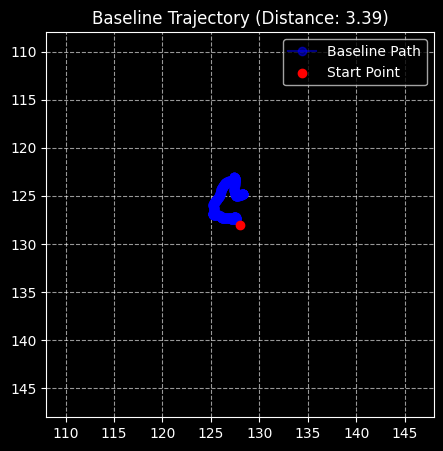

In [ ]:
#@title Simulate and Measure Baseline Locomotion
import matplotlib.pyplot as plt
import numpy as np # Added just in case

T = 750 # Number of steps to test

current_state = state_p

# Arrays to store the trajectory
base_com_x, base_com_y = [], []

# Coordinate grids for calculating Center of Mass (ij indexing means x=rows, y=cols)
x_grid, y_grid = np.meshgrid(np.arange(SX), np.arange(SY), indexing='ij')

print("Running Baseline Simulation...")

with VideoWriter("fl_baseline.mp4", 60) as vid:
    for i in range(T):
        current_state = fl_p_step_fn(current_state, c_params)
        A_frame = np.array(jax.block_until_ready(current_state.A))
        P_frame = np.array(current_state.P)

        # --- TRACKING CENTER OF MASS ---
        mass = np.sum(A_frame[..., 0])
        if mass > 0.1: # As long as the blob hasn't evaporated
            cx = np.sum(A_frame[..., 0] * x_grid) / mass
            cy = np.sum(A_frame[..., 0] * y_grid) / mass
        else:
            # If it dies, it stops moving
            cx, cy = base_com_x[-1], base_com_y[-1]

        base_com_x.append(cx)
        base_com_y.append(cy)

        vid.add(state2img_P(A_frame, P_frame))

# Calculate total distance traveled from the starting center (mx, my)
final_cx, final_cy = base_com_x[-1], base_com_y[-1]
baseline_distance = np.sqrt((final_cx - mx)**2 + (final_cy - my)**2)

print(f"--- BASELINE ESTABLISHED ---")
print(f"Distance Traveled: {baseline_distance:.2f} pixels")

# --- THE FIX: SWAPPED COORDINATES FOR PLOTTING ---
plt.figure(figsize=(5, 5))

# We plot base_com_y (columns) on the X-axis, and base_com_x (rows) on the Y-axis
plt.plot(base_com_y, base_com_x, marker='o', color='blue', alpha=0.5, label='Baseline Path')
plt.scatter([my], [mx], color='red', label='Start Point', zorder=5)

plt.title(f"Baseline Trajectory (Distance: {baseline_distance:.2f})")

# We use 'my' for the X-axis limits, and 'mx' for the Y-axis limits
plt.xlim(my-20, my+20)
# We invert the Y-axis so the top of the video (row 0) is the top of the graph
plt.ylim(mx+20, mx-20)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

vid.show(width=360, height=360)

## Simulation with Black Plots

Running Baseline Simulation...
--- BASELINE ESTABLISHED ---
Distance Traveled: 3.39 pixels


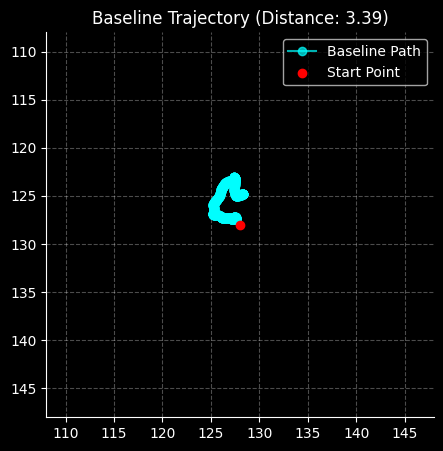

In [ ]:
#@title Simulate and Measure Baseline Locomotion
import matplotlib.pyplot as plt
import numpy as np # Added just in case

# --- ADDED: Set dark theme for the entire plot to match your simulation ---
plt.style.use('dark_background')

T = 750 # Number of steps to test

current_state = state_p

# Arrays to store the trajectory
base_com_x, base_com_y = [], []

# Coordinate grids for calculating Center of Mass (ij indexing means x=rows, y=cols)
x_grid, y_grid = np.meshgrid(np.arange(SX), np.arange(SY), indexing='ij')

print("Running Baseline Simulation...")

with VideoWriter("fl_baseline.mp4", 60) as vid:
    for i in range(T):
        current_state = fl_p_step_fn(current_state, c_params)
        A_frame = np.array(jax.block_until_ready(current_state.A))
        P_frame = np.array(current_state.P)

        # --- TRACKING CENTER OF MASS ---
        mass = np.sum(A_frame[..., 0])
        if mass > 0.1: # As long as the blob hasn't evaporated
            cx = np.sum(A_frame[..., 0] * x_grid) / mass
            cy = np.sum(A_frame[..., 0] * y_grid) / mass
        else:
            # If it dies, it stops moving
            cx, cy = base_com_x[-1], base_com_y[-1]

        base_com_x.append(cx)
        base_com_y.append(cy)

        vid.add(state2img_P(A_frame, P_frame))

# Calculate total distance traveled from the starting center (mx, my)
final_cx, final_cy = base_com_x[-1], base_com_y[-1]
baseline_distance = np.sqrt((final_cx - mx)**2 + (final_cy - my)**2)

print(f"--- BASELINE ESTABLISHED ---")
print(f"Distance Traveled: {baseline_distance:.2f} pixels")

# --- THE FIX: SWAPPED COORDINATES FOR PLOTTING ---
plt.figure(figsize=(5, 5))

# --- ADDED: Remove top and right borders for a cleaner look ---
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# We plot base_com_y (columns) on the X-axis, and base_com_x (rows) on the Y-axis
# Changed color to cyan for better contrast on a black background
plt.plot(base_com_y, base_com_x, marker='o', color='cyan', alpha=0.7, label='Baseline Path')
plt.scatter([my], [mx], color='red', label='Start Point', zorder=5)

plt.title(f"Baseline Trajectory (Distance: {baseline_distance:.2f})")

# We use 'my' for the X-axis limits, and 'mx' for the Y-axis limits
plt.xlim(my-20, my+20)
# We invert the Y-axis so the top of the video (row 0) is the top of the graph
plt.ylim(mx+20, mx-20)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.3) # Lowered alpha to make the grid softer
plt.show()

vid.show(width=360, height=360)

# Modifications (iteration 1 )

Evolving the smooth brain...
Gen 1 | Learned better locomotion! Distance: 3.63
Gen 2 | Learned better locomotion! Distance: 4.46
Gen 3 | Learned better locomotion! Distance: 7.70
Gen 5 | Learned better locomotion! Distance: 16.34
Gen 6 | Learned better locomotion! Distance: 29.71
Gen 15 | Learned better locomotion! Distance: 38.36
Gen 18 | Learned better locomotion! Distance: 39.20
Gen 19 | Learned better locomotion! Distance: 49.52
Gen 21 | Learned better locomotion! Distance: 52.17

Rendering smooth final agent...


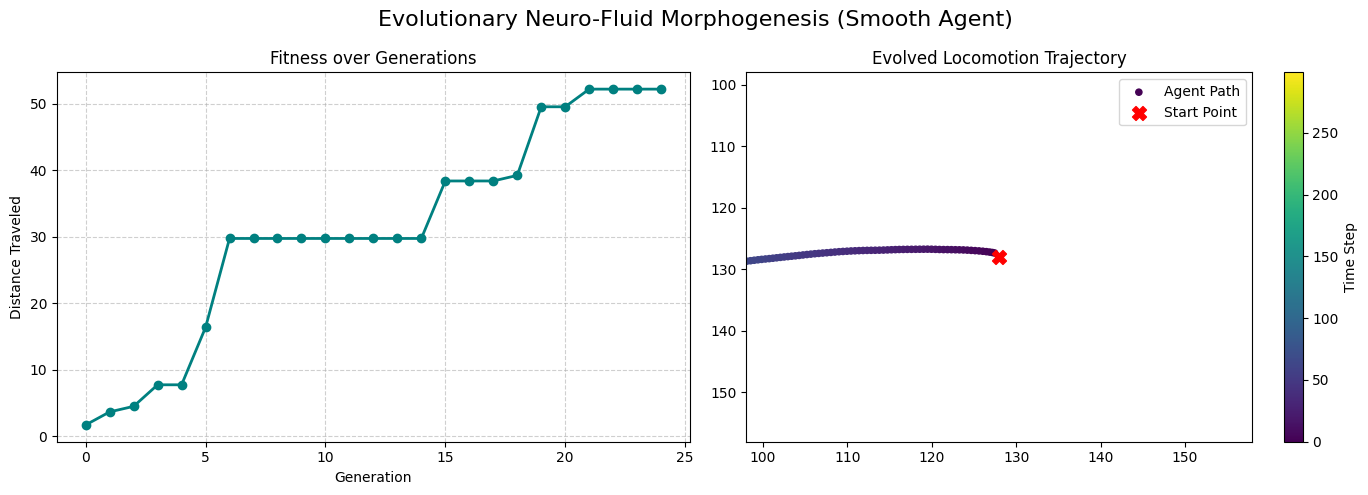

In [ ]:
#@title The Upgraded Neuro-Fluid Pipeline (Smooth & Stable)
import time
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. THE UPGRADED BRAIN (Smooth & Stable)
# ==========================================
@jax.jit
def neuro_step(state: State_P, params: CompiledParams, W: jnp.ndarray) -> State_P:
    A, P_base = state.A, state.P

    # Sense the environment
    C_grad = sobel(A.sum(axis = -1, keepdims = True))

    # --- The Fix: Bounded Phenotype Flexing ---
    # We pass the gradient through tanh to prevent massive spikes.
    # We multiply by 0.15 to limit the brain to a max 15% shift in parameters.
    brain_modulation = jnp.tanh(jnp.dot(C_grad[..., 0], W)) * 0.15

    # The brain flexes the parameters temporarily (Phenotype)
    P_pheno = jnp.clip(P_base + brain_modulation, 0.0, 1.0)

    # Calculate physics using the FLEXED parameters
    fA = jnp.fft.fft2(A, axes=(0,1))
    fAk = fA[:, :, fl_p.config.c0]
    U = jnp.real(jnp.fft.ifft2(params.fK * fAk, axes=(0,1)))
    U = growth(U, params.m, params.s) * P_pheno # <--- Brain affects growth here
    U = jnp.dstack([ U[:, :, fl_p.config.c1[c]].sum(axis=-1) for c in range(fl_p.config.C) ])

    F = sobel(U)
    alpha = jnp.clip((A[:, :, None, :]/2)**2, .0, 1.)
    F_base = jnp.clip(F * (1 - alpha) - C_grad * alpha, - (fl_p.config.dd-fl_p.config.sigma), fl_p.config.dd - fl_p.config.sigma)

    # --- The Fix: Stable Reintegration ---
    # We transport the mass (A) and the BASE DNA (P_base), so the organism stays stable!
    nA, nP_base = fl_p.RT.apply(A, P_base, F_base)

    return State_P(A=nA, P=nP_base)

# ==========================================
# 2. EVOLUTIONARY SEARCH
# ==========================================
x_grid, y_grid = np.meshgrid(np.arange(SX), np.arange(SY), indexing='ij')

def evaluate_fitness(W_matrix, init_state, steps=750):
    current = init_state
    for _ in range(steps):
        current = neuro_step(current, c_params, W_matrix)
    final_A = np.array(jax.block_until_ready(current.A))

    mass = np.sum(final_A[..., 0])
    if mass < 1.0: return 0.0

    cx = np.sum(final_A[..., 0] * x_grid) / mass
    cy = np.sum(final_A[..., 0] * y_grid) / mass
    return np.sqrt((cx - mx)**2 + (cy - my)**2)

print("Evolving the smooth brain")
best_W = jax.random.normal(jax.random.PRNGKey(42), (2, fl_p.config.nb_k)) * 0.1
best_fitness = evaluate_fitness(best_W, state_p)
fitness_history = [best_fitness]

for gen in range(1, 25): # 25 Generations for speed
    noise = jax.random.normal(jax.random.PRNGKey(gen), best_W.shape) * 0.2
    mutant_W = best_W + noise
    mutant_fitness = evaluate_fitness(mutant_W, state_p)

    if mutant_fitness > best_fitness:
        best_W = mutant_W
        best_fitness = mutant_fitness
        print(f"Gen {gen} | Learned better locomotion! Distance: {best_fitness:.2f}")
    fitness_history.append(best_fitness)

# ==========================================
# 3. BULLETPROOF RENDERER & PLOT
# ==========================================
def state2img_clean(A):
    # This guarantees the video writer sees a standard RGB image, fixing the dotted artifacts
    C = A.shape[-1]
    if C == 1:
        return np.repeat(A, 3, axis=-1) # Forces grayscale to 3-channel RGB
    if C == 2:
        return np.dstack([A[..., 0], A[..., 0], A[..., 1]])
    return A[..., :3]

T = 750
current_state = state_p
evo_com_x, evo_com_y = [], []

print("\nRendering smooth final agent...")
with VideoWriter("evolved_neuro_agent_perfect.mp4", 60) as vid:
    for i in range(T):
        current_state = neuro_step(current_state, c_params, best_W)
        A_frame = np.array(jax.block_until_ready(current_state.A))

        mass = np.sum(A_frame[..., 0])
        if mass > 0.1:
            cx = np.sum(A_frame[..., 0] * x_grid) / mass
            cy = np.sum(A_frame[..., 0] * y_grid) / mass
        else:
            cx, cy = evo_com_x[-1], evo_com_y[-1]

        evo_com_x.append(cx)
        evo_com_y.append(cy)
        vid.add(state2img_clean(A_frame))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) # <-- THIS IS THE FIXED LINE
fig.suptitle('Evolutionary Neuro-Fluid Morphogenesis (Smooth Agent)', fontsize=16)

ax1.plot(fitness_history, color='teal', linewidth=2, marker='o')
ax1.set_title('Fitness over Generations')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Distance Traveled')
ax1.grid(True, linestyle='--', alpha=0.6)

# --- THE FIX FOR THE TRAJECTORY PLOT ---
# We swap evo_com_x and evo_com_y to match Image (Column, Row) to Plot (X, Y)
sc = ax2.scatter(evo_com_y, evo_com_x, c=np.arange(T), cmap='viridis', s=20, label='Agent Path')
ax2.scatter([my], [mx], color='red', marker='X', s=100, label='Start Point', zorder=5)

ax2.set_title('Evolved Locomotion Trajectory')
ax2.set_xlim(my-30, my+30)
ax2.set_ylim(mx+30, mx-30) # We invert the Y-axis limits so the top of the video is the top of the graph!
ax2.legend()
plt.colorbar(sc, ax=ax2, label='Time Step')

plt.tight_layout()
plt.show()

vid.show(width=360, height=360)

# Iteration 2 (Modified)

Evolving the smooth brain...
Gen 0 | Improved! Distance: 4.62
Gen 1 | Improved! Distance: 9.41
Gen 8 | Improved! Distance: 10.08
Gen 9 | Improved! Distance: 10.74
Gen 11 | Improved! Distance: 11.79
Gen 13 | Improved! Distance: 17.22
Gen 18 | Improved! Distance: 24.31
Gen 20 | Improved! Distance: 27.95

Rendering videos and plots...
Rendering Gen 0 (No Brain) → neuro_gen_0.mp4


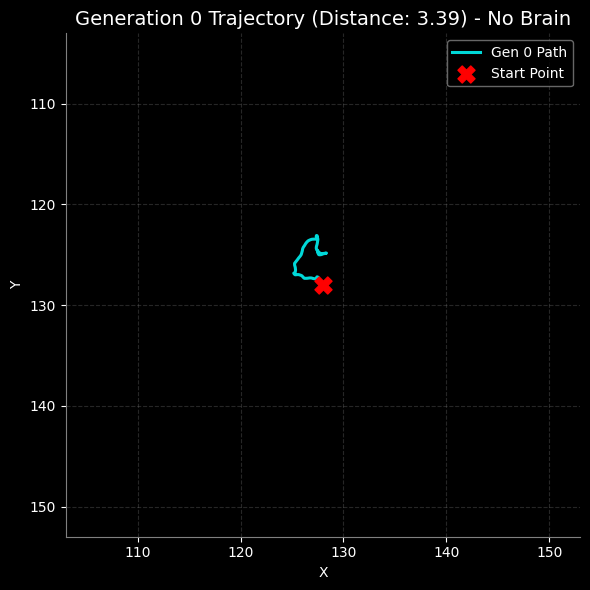

Rendering Gen 1 (With Brain) → neuro_gen_1.mp4


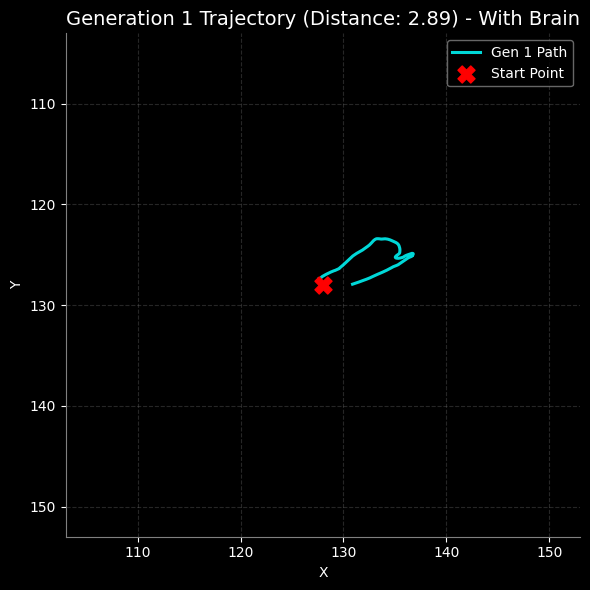

Rendering Gen 2 (With Brain) → neuro_gen_2.mp4


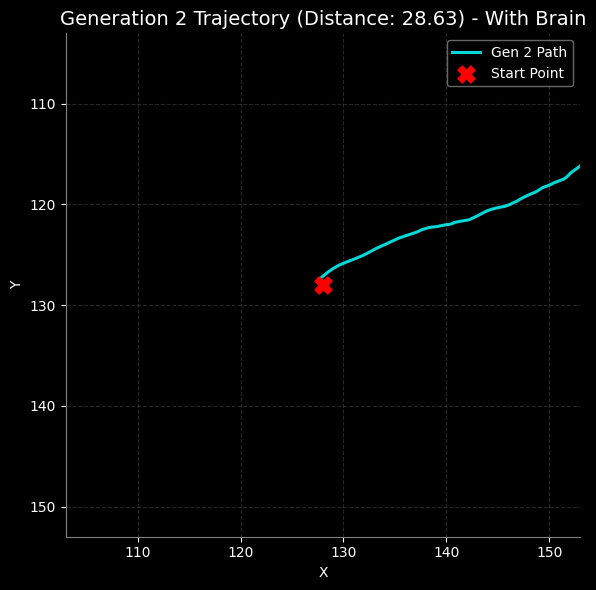

Rendering Gen 8 (With Brain) → neuro_gen_8.mp4


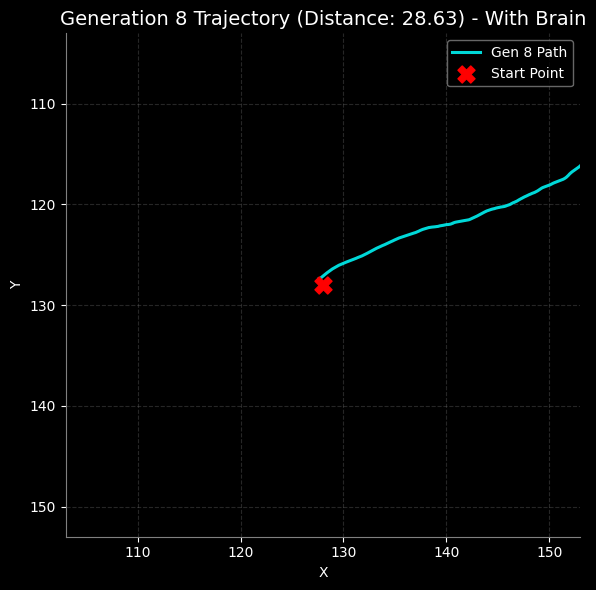

Rendering Gen 10 (With Brain) → neuro_gen_10.mp4


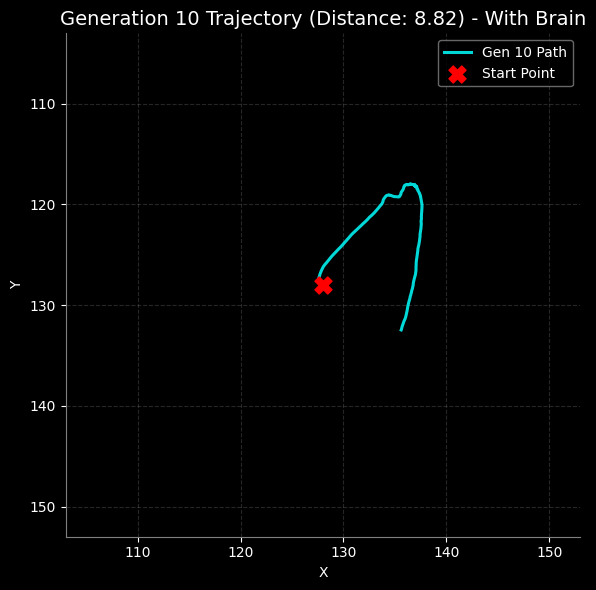

Rendering Gen 15 (With Brain) → neuro_gen_15.mp4


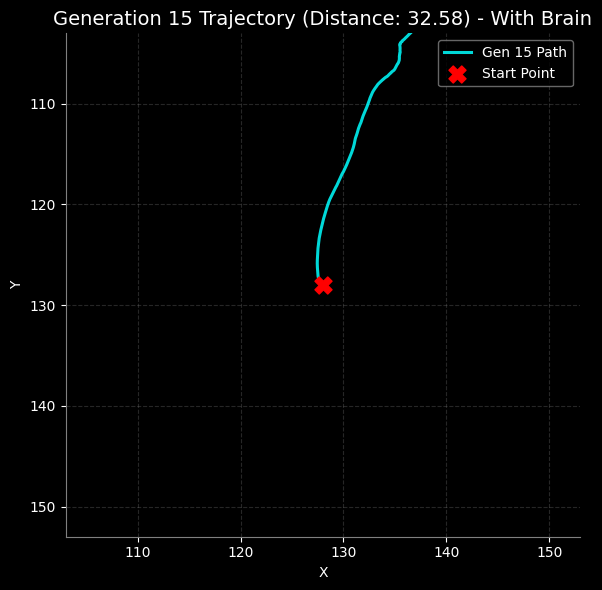

Rendering Gen 20 (With Brain) → neuro_gen_20.mp4


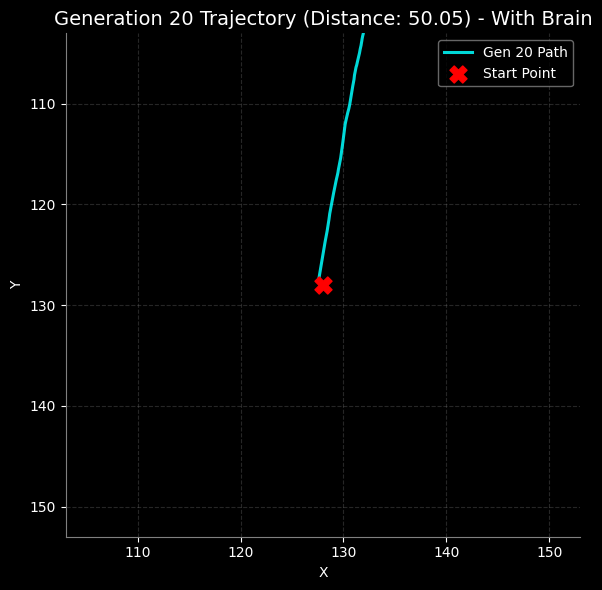

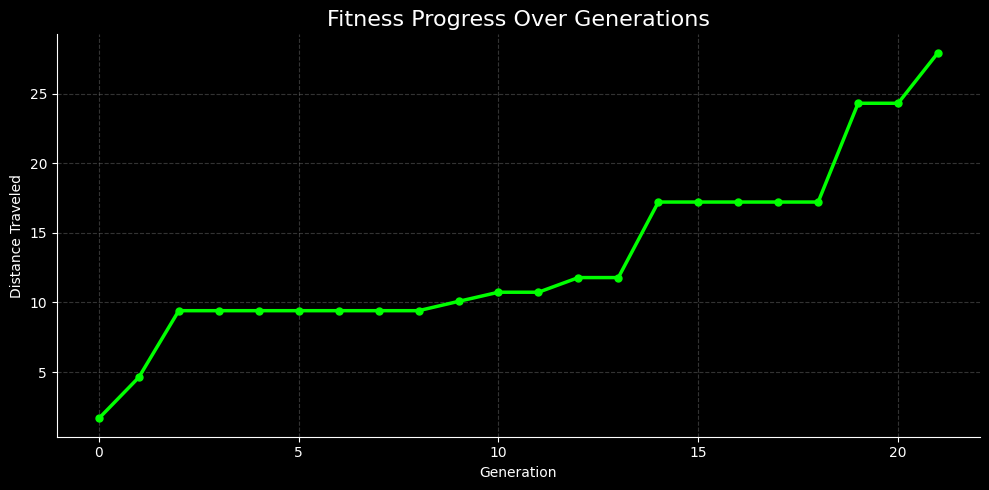


All done! Gen 0 should now match your baseline (white + similar movement).


In [ ]:
#@title Neuro-Fluid Pipeline - Gen0 = No Brain + Matching Baseline Plots

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# ==========================================
# 1. NEURO STEP (with static use_brain)
# ==========================================
@partial(jax.jit, static_argnums=(3,))
def neuro_step(state: State_P, params: CompiledParams, W: jnp.ndarray, use_brain: bool = True) -> State_P:
    A, P_base = state.A, state.P
    C_grad = sobel(A.sum(axis = -1, keepdims = True))

    if use_brain:
        brain_modulation = jnp.tanh(jnp.dot(C_grad[..., 0], W)) * 0.15
        P_pheno = jnp.clip(P_base + brain_modulation, 0.0, 1.0)
    else:
        P_pheno = P_base   # ← Gen 0: No brain, same as baseline

    # Lenia Physics
    fA = jnp.fft.fft2(A, axes=(0,1))
    fAk = fA[:, :, fl_p.config.c0]
    U = jnp.real(jnp.fft.ifft2(params.fK * fAk, axes=(0,1)))
    U = growth(U, params.m, params.s) * P_pheno
    U = jnp.dstack([ U[:, :, fl_p.config.c1[c]].sum(axis=-1) for c in range(fl_p.config.C) ])

    F = sobel(U)
    alpha = jnp.clip((A[:, :, None, :]/2)**2, .0, 1.)
    F_base = jnp.clip(F * (1 - alpha) - C_grad * alpha,
                      -(fl_p.config.dd - fl_p.config.sigma),
                      fl_p.config.dd - fl_p.config.sigma)

    nA, nP_base = fl_p.RT.apply(A, P_base, F_base)
    return State_P(A=nA, P=nP_base)

# ==========================================
# 2. EVOLUTION (Brain always ON)
# ==========================================
x_grid, y_grid = np.meshgrid(np.arange(SX), np.arange(SY), indexing='ij')

def evaluate_fitness(W_matrix, init_state, steps=120):
    current = init_state
    for _ in range(steps):
        current = neuro_step(current, c_params, W_matrix, use_brain=True)
    final_A = np.array(jax.block_until_ready(current.A))
    mass = np.sum(final_A[..., 0])
    if mass < 1.0: return 0.0
    cx = np.sum(final_A[..., 0] * x_grid) / mass
    cy = np.sum(final_A[..., 0] * y_grid) / mass
    return np.sqrt((cx - mx)**2 + (cy - my)**2)

print("Evolving the smooth brain...")
best_W = jax.random.normal(jax.random.PRNGKey(42), (2, fl_p.config.nb_k)) * 0.1
best_fitness = evaluate_fitness(best_W, state_p)
fitness_history = [best_fitness]
W_history = [best_W.copy()]

for gen in range(0,21):
    noise = jax.random.normal(jax.random.PRNGKey(gen), best_W.shape) * 0.2
    mutant_W = best_W + noise
    mutant_fitness = evaluate_fitness(mutant_W, state_p)

    if mutant_fitness > best_fitness:
        best_W = mutant_W
        best_fitness = mutant_fitness
        print(f"Gen {gen} | Improved! Distance: {best_fitness:.2f}")

    fitness_history.append(best_fitness)
    W_history.append(best_W.copy())

# ==========================================
# 3. RENDERING + MATCHING BASELINE-STYLE PLOTS
# ==========================================
def state2img_clean(A):
    C = A.shape[-1]
    if C == 2:
        return np.dstack([A[..., 0], A[..., 0], A[..., 1]])  # Yellow + Blue
    return np.repeat(A, 3, axis=-1) if C == 1 else A[..., :3]

gens_to_render = [0, 1, 2,8,10,15,20]

print("\nRendering videos and plots...")

for gen in gens_to_render:
    W = W_history[gen] if gen < len(W_history) else best_W
    use_brain_flag = False if gen == 0 else True

    current_state = state_p
    com_x, com_y = [], []

    filename = f"neuro_gen_{gen}.mp4"
    brain_status = "No Brain" if not use_brain_flag else "With Brain"

    print(f"Rendering Gen {gen} ({brain_status}) → {filename}")

    with VideoWriter(filename, fps=60) as vid:
        for i in range(750):
            current_state = neuro_step(current_state, c_params, W, use_brain=use_brain_flag)
            A_frame = np.array(jax.block_until_ready(current_state.A))

            mass = np.sum(A_frame[..., 0])
            if mass > 0.1:
                cx = np.sum(A_frame[..., 0] * x_grid) / mass
                cy = np.sum(A_frame[..., 0] * y_grid) / mass
            else:
                cx, cy = com_x[-1] if com_x else mx, com_y[-1] if com_y else my

            com_x.append(cx)
            com_y.append(cy)
            vid.add(state2img_clean(A_frame))

    # === FINAL DISTANCE CALCULATION ===
    final_cx, final_cy = com_x[-1], com_y[-1]
    distance = np.sqrt((final_cx - mx)**2 + (final_cy - my)**2)

    # === MATCHING BASELINE STYLE PLOT ===
    plt.figure(figsize=(6, 6), facecolor='black')
    ax = plt.gca()
    ax.set_facecolor('black')

    plt.plot(com_y, com_x, color='cyan', linewidth=2.2, alpha=0.85, label=f'Gen {gen} Path')
    plt.scatter([my], [mx], color='red', marker='X', s=150, label='Start Point', zorder=5)

    plt.title(f'Generation {gen} Trajectory (Distance: {distance:.2f}) - {brain_status}',
              color='white', fontsize=14)
    plt.xlabel('X', color='white')
    plt.ylabel('Y', color='white')

    plt.xlim(my-25, my+25)
    plt.ylim(mx+25, mx-25)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('gray')
    ax.spines['left'].set_color('gray')
    ax.tick_params(colors='white')
    plt.grid(True, linestyle='--', alpha=0.3, color='gray')
    plt.legend(facecolor='black', edgecolor='gray', labelcolor='white')
    plt.tight_layout()
    plt.show()

# Final Fitness Plot
plt.figure(figsize=(10, 5), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')
plt.plot(fitness_history, color='lime', linewidth=2.5, marker='o', markersize=5)
plt.title('Fitness Progress Over Generations', color='white', fontsize=16)
plt.xlabel('Generation', color='white')
plt.ylabel('Distance Traveled', color='white')
plt.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

print("\nAll done! Gen 0 should now match your baseline (white + similar movement).")